1. Bond Orders & Edge TypesSMILES uses explicit punctuation characters between atom symbols to define the type and order of a bond.SINGLE (1.0): Implicit. You do not need to write anything between the atoms (e.g., CC for ethane). If explicitly required by a parser, use a hyphen -.DOUBLE (2.0): Represented by an equals sign =.TRIPLE (3.0): Represented by a hashtag/pound sign #.AROMATIC (1.5): Represented by lowercase atom symbols instead of bond symbols. For example, c1ccccc1 (Benzene) automatically implies aromatic (1.5) bonds between the carbons. If you must explicitly draw an aromatic bond symbol, use a colon :.

2. Aromatic vs. AliphaticThis is handled by character casing for the atoms sharing the edge, rather than a bond symbol.True: Use lowercase letters for the atoms (e.g., c, n, o).False: Use uppercase letters for the atoms (e.g., C, N, O).

3. Ring (Ring Closure)SMILES represents rings by "breaking" a bond and placing a matching integer ID immediately after the two atoms that form the edge.True: Add a matching digit to the connected atoms (e.g., C1...C1). For datasets with many rings where digits run out, use a percent sign followed by two digits (e.g., C%12...C%12).False: Standard linear string sequence with no matching digits.

4. ConjugationConjugated (True/False): Standard SMILES does not have a unique character for conjugation. Instead, conjugation is implicitly calculated by chemical software (like RDKit) based on the arrangement of alternating single/double/triple/aromatic bonds in the string.

5. Stereochemistry (Stereo)Double bond stereochemistry (Cis/Trans or E/Z) is represented using directional slashes on the bonds adjacent to the double bond.STEREONONE: Standard bond presentation (e.g., C=C).STEREOANY / SPECIFIC: Use forward slashes / and backslashes \ to show the spatial direction of the single bonds relative to the double bond.Trans (E): F/C=C/F or F\C=C\F (Slashes point in the same direction).Cis (Z): F/C=C\F or F\C=C/F (Slashes point in opposite directions).

In [ ]:
from rdkit import Chem

def extract_edge_attributes(smiles_string):
    # 1. Parse the SMILES string into an RDKit molecule object
    # Chem.AddHs(mol) can be used if you want to explicitly include Hydrogen edges
    mol = Chem.MolFromSmiles(smiles_string)

    if mol is None:
        return "Invalid SMILES string"

    print(f"Molecule: {smiles_string}")
    print("-" * 60)

    # 2. Iterate through all bonds (edges) in the molecule
    for bond in mol.GetBonds():
        # Get index of the two atoms connected by this edge
        begin_atom_idx = bond.GetBeginAtomIdx()
        end_atom_idx = bond.GetEndAtomIdx()
        begin_atom_symbol = bond.GetBeginAtom().GetSymbol()
        end_atom_symbol = bond.GetEndAtom().GetSymbol()

        # 3. Extract your exact dataset attributes
        edge_type = str(bond.GetBondType())       # SINGLE, DOUBLE, TRIPLE, AROMATIC
        bond_order = bond.GetBondTypeAsDouble()   # 1.0, 2.0, 3.0, 1.5
        is_aromatic = bond.GetIsAromatic()        # True / False
        is_in_ring = bond.IsInRing()              # True / False
        is_conjugated = bond.GetIsConjugated()    # True / False
        stereo_type = str(bond.GetStereo())       # STEREONONE, STEREOE, STEREOZ, etc.

        # 4. Print the extracted features for this edge
        print(f"Edge: {begin_atom_symbol}(idx:{begin_atom_idx}) <---> {end_atom_symbol}(idx:{end_atom_idx})")
        print(f"  └─ Edge Type:    {edge_type}")
        print(f"  └─ Bond Order:   {bond_order}")
        print(f"  └─ Aromatic:     {is_aromatic}")
        print(f"  └─ Ring:         {is_in_ring}")
        print(f"  └─ Conjugated:   {is_conjugated}")
        print(f"  └─ Stereo:       {stereo_type}")
        print("-" * 60)

In [ ]:
# --- Test the function ---
# Using the Fumaric Acid example from earlier (contains stereo, conjugation, single/double bonds)
test_smiles = "O=C(O)/C=C/C(=O)O"  # smiles string
extract_edge_attributes(test_smiles)

In [ ]:
# # ============================================================
# # COMPLETE PIPELINE:
# # User Input -> RDKit Molecule -> Graph Generation
# # WITH NODE FEATURES + EDGE FEATURES
# # ============================================================
#
# # Install required packages:
# # pip install rdkit-pypi torch torch-geometric networkx matplotlib
#
# from rdkit import Chem
# from rdkit.Chem import Draw
# from rdkit.Chem.rdchem import HybridizationType
# import torch
# from torch_geometric.data import Data
# import networkx as nx
# import matplotlib.pyplot as plt
#
#
# # ============================================================
# # 1. USER INPUT
# # ============================================================
#
# # Example SMILES string
# # Aspirin molecule
# smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"
#
# # Convert SMILES -> RDKit Molecule Object
# mol = Chem.MolFromSmiles(smiles)
#
# if mol is None:
#     raise ValueError("Invalid SMILES string")
#
#
# # ============================================================
# # 2. NODE FEATURE EXTRACTION
# # ============================================================
#
# def get_atom_features(atom):
#
#     """
#     Extract node (atom) features
#     """
#
#     hybridization_map = {
#         HybridizationType.SP: 0,
#         HybridizationType.SP2: 1,
#         HybridizationType.SP3: 2,
#         HybridizationType.SP3D: 3,
#         HybridizationType.SP3D2: 4
#     }
#
#     features = [
#
#         # Atomic number
#         atom.GetAtomicNum(),
#
#         # Degree
#         atom.GetDegree(),
#
#         # Formal charge
#         atom.GetFormalCharge(),
#
#         # Aromaticity
#         int(atom.GetIsAromatic()),
#
#         # Number of hydrogens
#         atom.GetTotalNumHs(),
#
#         # Hybridization
#         hybridization_map.get(atom.GetHybridization(), -1),
#
#         # In ring
#         int(atom.IsInRing()),
#
#         # Chirality
#         int(atom.HasProp('_ChiralityPossible'))
#     ]
#
#     return features
#
#
# # Extract node features
# node_features = []
#
# for atom in mol.GetAtoms():
#
#     node_features.append(get_atom_features(atom))
#
# # Convert to tensor
# x = torch.tensor(node_features, dtype=torch.float)
#
# print("================================================")
# print("NODE FEATURE MATRIX")
# print("================================================")
# print(x)
# print("Shape:", x.shape)
#
#
# # ============================================================
# # 3. EDGE EXTRACTION
# # ============================================================
#
# def get_bond_features(bond):
#
#     """
#     Extract edge (bond) features
#     """
#
#     features = [
#
#         # Bond type
#         bond.GetBondTypeAsDouble(),
#
#         # Conjugation
#         int(bond.GetIsConjugated()),
#
#         # Ring membership
#         int(bond.IsInRing()),
#
#         # Aromatic
#         int(bond.GetIsAromatic())
#     ]
#
#     return features
#
#
# edge_indices = []
# edge_features = []
#
# for bond in mol.GetBonds():
#
#     start = bond.GetBeginAtomIdx()
#     end = bond.GetEndAtomIdx()
#
#     # Add both directions
#     edge_indices.append([start, end])
#     edge_indices.append([end, start])
#
#     features = get_bond_features(bond)
#
#     edge_features.append(features)
#     edge_features.append(features)
#
#
# # Convert edge index to tensor
# edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
#
# # Convert edge features to tensor
# edge_attr = torch.tensor(edge_features, dtype=torch.float)
#
# print("\n================================================")
# print("EDGE INDEX")
# print("================================================")
# print(edge_index)
#
# print("\n================================================")
# print("EDGE FEATURES")
# print("================================================")
# print(edge_attr)
# print("Shape:", edge_attr.shape)
#
#
# # ============================================================
# # 4. CREATE PYTORCH GEOMETRIC GRAPH
# # ============================================================
#
# graph_data = Data(
#     x=x,
#     edge_index=edge_index,
#     edge_attr=edge_attr
# )
#
# print("\n================================================")
# print("PYTORCH GEOMETRIC GRAPH")
# print("================================================")
# print(graph_data)
#
#
# # ============================================================
# # 5. VISUALIZE MOLECULE
# # ============================================================
#
# # RDKit molecule image
# img = Draw.MolToImage(mol, size=(500, 500))
#
# plt.figure(figsize=(6,6))
# plt.imshow(img)
# plt.axis("off")
# plt.title("Molecular Structure")
# plt.show()
#
#
# # ============================================================
# # 6. VISUALIZE GRAPH STRUCTURE
# # ============================================================
#
# G = nx.Graph()
#
# # Add nodes
# for atom in mol.GetAtoms():
#
#     idx = atom.GetIdx()
#
#     G.add_node(
#         idx,
#         symbol=atom.GetSymbol()
#     )
#
# # Add edges
# for bond in mol.GetBonds():
#
#     start = bond.GetBeginAtomIdx()
#     end = bond.GetEndAtomIdx()
#
#     G.add_edge(start, end)
#
# # Draw graph
# plt.figure(figsize=(8,8))
#
# pos = nx.spring_layout(G)
#
# labels = nx.get_node_attributes(G, 'symbol')
#
# nx.draw(
#     G,
#     pos,
#     with_labels=True,
#     labels=labels,
#     node_size=1200,
#     font_size=12
# )
#
# plt.title("Graph Representation of Molecule")
# plt.show()
#
#
# # ============================================================
# # 7. DISPLAY COMPLETE INFORMATION
# # ============================================================
#
# print("\n================================================")
# print("COMPLETE GRAPH INFORMATION")
# print("================================================")
#
# print(f"Number of atoms (nodes): {mol.GetNumAtoms()}")
# print(f"Number of bonds (edges): {mol.GetNumBonds()}")
#
# print("\nNode Features:")
# for i, atom in enumerate(mol.GetAtoms()):
#
#     print(f"\nNode {i} ({atom.GetSymbol()}):")
#     print(node_features[i])
#
# print("\nEdge Features:")
# for i, bond in enumerate(mol.GetBonds()):
#
#     print(
#         f"\nBond {bond.GetBeginAtomIdx()} -> "
#         f"{bond.GetEndAtomIdx()}:"
#     )
#
#     print(get_bond_features(bond))
#
#
# # ============================================================
# # FINAL OUTPUTS YOU WILL USE
# # ============================================================
#
# print("\n================================================")
# print("FINAL OUTPUTS")
# print("================================================")
#
# print("graph_data.x")
# print("-> Node feature matrix")
#
# print("\ngraph_data.edge_index")
# print("-> Graph connectivity")
#
# print("\ngraph_data.edge_attr")
# print("-> Edge feature matrix")
#
# print("\nThese can now be directly used in:")
# print("- GNN")
# print("- MPNN")
# print("- Sparse Dictionary Learning")
# print("- Graph Classification")

Draw the molecule if the smile string is given

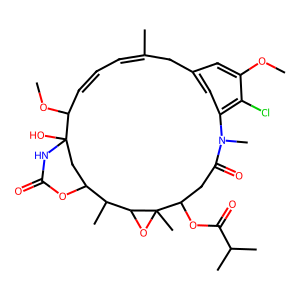

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

smiles = "COc1cc2cc(c1Cl)N(C)C(=O)CC(OC(=O)C(C)C)C1(C)OC1C(C)C1CC(O)(NC(=O)O1)C(OC)C=CC=C(C)C2"   # benzene

mol = Chem.MolFromSmiles(smiles)

display(Draw.MolToImage(mol))

Bioavailability Radar

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski
import matplotlib.pyplot as plt
import numpy as np

# SMILES
smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"
mol = Chem.MolFromSmiles(smiles)

# Compute descriptors
mw = Descriptors.MolWt(mol)
logp = Crippen.MolLogP(mol)
tpsa = Descriptors.TPSA(mol)
rot_bonds = Lipinski.NumRotatableBonds(mol)
fsp3 = Lipinski.FractionCSP3(mol)
hbd = Lipinski.NumHDonors(mol)

labels = ['MW', 'LogP', 'TPSA', 'RotB', 'Fsp3', 'HBD']
values = [mw/100, logp, tpsa/20, rot_bonds, fsp3*10, hbd]

# Close the radar
values += values[:1]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# WHITE STYLE
fig, ax = plt.subplots(
    figsize=(6,6),
    subplot_kw=dict(polar=True),
    facecolor="white"
)

ax.set_facecolor("white")

# Radar line
ax.plot(angles, values, color="red", linewidth=2)

# Fill
ax.fill(angles, values, color="red", alpha=0.25)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, color="black", fontsize=12)

# Grid styling
ax.grid(color="gray", alpha=0.3)

# Title
plt.title("Bioavailability Radar", color="black", fontsize=14)

plt.show()

get smiles from nci1

In [1]:
from rdkit import Chem
import networkx as nx

print('Loading NCI1 dataset')

graphs = []
y = []
smiles_list = []

filepath = "datasets/NCI_full/1total-connect.sdf"

supplier = Chem.SDMolSupplier(filepath, removeHs=False)

for mol in supplier:
    if mol is None:
        continue

    # Convert molecule to SMILES
    smiles = Chem.MolToSmiles(mol)

    G = nx.Graph()

    # Add atoms as nodes
    for atom in mol.GetAtoms():
        G.add_node(
            atom.GetIdx(),
            label=atom.GetSymbol()
        )

    # Add bonds as edges
    for bond in mol.GetBonds():
        G.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=str(bond.GetBondType()),
            bond_order=bond.GetBondTypeAsDouble(),
            aromatic=bond.GetIsAromatic(),
            in_ring=bond.IsInRing(),
            conjugated=bond.GetIsConjugated(),
            stereo=str(bond.GetStereo())
        )

    # Graph label
    label = int(float(mol.GetProp("value")))

    graphs.append(G)
    y.append(label)
    smiles_list.append(smiles)

print(f"Loaded {len(graphs)} graphs")
print(f"Loaded {len(smiles_list)} SMILES strings")

# Example
print(smiles_list[0])

Loading NCI1 dataset


[12:47:35] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[12:47:35] ERROR: Could not sanitize molecule ending on line 5976
[12:47:35] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[12:47:35] Explicit valence for atom # 0 Br, 1, is greater than permitted
[12:47:35] ERROR: Could not sanitize molecule ending on line 9488
[12:47:35] ERROR: Explicit valence for atom # 0 Br, 1, is greater than permitted
[12:47:35] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[12:47:35] ERROR: Could not sanitize molecule ending on line 12926
[12:47:35] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[12:47:35] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[12:47:35] ERROR: Could not sanitize molecule ending on line 13981
[12:47:35] ERROR: Explicit valence for atom # 1 Cl, 1, is greater than permitted
[12:47:35] Explicit valence for atom # 1 Cl, 1, is greater than permitted
[12:47:35] ERROR: Could not sanitize mol

Loaded 36937 graphs
Loaded 36937 SMILES strings
COc1cc2cc(c1Cl)N(C)C(=O)CC(OC(=O)C(C)C)C1(C)OC1C(C)C1CC(O)(NC(=O)O1)C(OC)C=CC=C(C)C2
